In [21]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns
pd.set_option('display.max_columns', None)

In [22]:
df = pd.read_csv(r"../data/Amazon.csv")
print(df.head()) 
print(df.shape)
print(df.columns)
print(df.info()) 

                         Timestamp  age             Gender  \
0   2023/06/08 7:50:55 PM GMT+5:30   65  Prefer not to say   
1   2023/06/09 9:37:44 AM GMT+5:30   20               Male   
2  2023/06/11 11:26:54 PM GMT+5:30   42               Male   
3   2023/06/08 5:17:10 PM GMT+5:30   65             Others   
4  2023/06/11 10:59:30 PM GMT+5:30   45             Female   

       Purchase_Frequency                                Purchase_Categories  \
0  Less than once a month                               Clothing and Fashion   
1             Once a week  Groceries and Gourmet Food;Beauty and Personal...   
2             Once a week  Groceries and Gourmet Food;Beauty and Personal...   
3            Once a month  Beauty and Personal Care;Clothing and Fashion;...   
4             Once a week  Beauty and Personal Care;Clothing and Fashion;...   

  Personalized_Recommendation_Frequency    Browsing_Frequency  \
0                                   Yes  Multiple times a day   
1               

In [23]:
df.columns = df.columns.str.strip()

In [24]:
duplicate_columns = df.columns[df.columns.duplicated()].tolist()
duplicate_columns

['Personalized_Recommendation_Frequency']

In [25]:
for i, col in enumerate(df.columns):
    print(i, col)

0 Timestamp
1 age
2 Gender
3 Purchase_Frequency
4 Purchase_Categories
5 Personalized_Recommendation_Frequency
6 Browsing_Frequency
7 Product_Search_Method
8 Search_Result_Exploration
9 Customer_Reviews_Importance
10 Add_to_Cart_Browsing
11 Cart_Completion_Frequency
12 Cart_Abandonment_Factors
13 Saveforlater_Frequency
14 Review_Left
15 Review_Reliability
16 Review_Helpfulness
17 Personalized_Recommendation_Frequency
18 Recommendation_Helpfulness
19 Rating_Accuracy
20 Shopping_Satisfaction
21 Service_Appreciation
22 Improvement_Areas
23 transaction


In [26]:
cols = list(df.columns)

cols[5] = "Recommendation_Response"
cols[17] = "Recommendation_Score"

df.columns = cols

In [27]:
columns = [
    "Gender",
    "Purchase_Frequency",
    "Recommendation_Helpfulness",
    "Review_Reliability",
    "Product_Search_Method"
]

for col in columns:
    print("=" * 50)
    print(f"Column: {col}")
    print("=" * 50)
    
    print(f"Unique Values ({df[col].nunique()}):")
    print(df[col].unique())
    
    print("\nValue Counts:")
    print(df[col].value_counts(dropna=False))
    
    print("\n")

Column: Gender
Unique Values (4):
<StringArray>
['Prefer not to say', 'Male', 'Others', 'Female']
Length: 4, dtype: str

Value Counts:
Gender
Male                 209
Others               202
Female               197
Prefer not to say    192
Name: count, dtype: int64


Column: Purchase_Frequency
Unique Values (5):
<StringArray>
['Less than once a month',            'Once a week',           'Once a month',
      'Few times a month',  'Multiple times a week']
Length: 5, dtype: str

Value Counts:
Purchase_Frequency
Once a month              168
Once a week               159
Multiple times a week     159
Few times a month         158
Less than once a month    156
Name: count, dtype: int64


Column: Recommendation_Helpfulness
Unique Values (3):
<StringArray>
['Sometimes', 'No', 'Yes']
Length: 3, dtype: str

Value Counts:
Recommendation_Helpfulness
Yes          270
Sometimes    268
No           262
Name: count, dtype: int64


Column: Review_Reliability
Unique Values (5):
<StringArray>
['Mode

In [28]:
# Replacing null value with Unknown in Product_Search_Method
df["Product_Search_Method"] = df["Product_Search_Method"].fillna("Unknown")
df["Product_Search_Method"] = df["Product_Search_Method"].str.strip().str.title()

In [29]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Recommendation_Response,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Recommendation_Score,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,No,Sometimes,Found a better price elsewhere,Sometimes,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,No,Never,High shipping costs,Always,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,No,Rarely,Found a better price elsewhere,Often,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,Yes,Sometimes,others,Often,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Unknown,First page,5,Maybe,Rarely,Changed my mind or no longer need the item,Never,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642


# Task 2

In [32]:
print(df["age"].describe())

count    800.000000
mean      35.170000
std       18.916485
min        3.000000
25%       19.000000
50%       35.500000
75%       51.000000
max       67.000000
Name: age, dtype: float64


In [35]:
bins = [0, 12, 19, 35, 50, np.inf]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["Age_Group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

In [37]:
df[["age", "Age_Group"]].head()

,age,Age_Group
0,65,Senior
1,20,Young Adult
2,42,Adult
3,65,Senior
4,45,Adult


In [38]:
df["Age_Group"].value_counts()

Age_Group
Senior         215
Young Adult    195
Adult          185
Child          123
Teen            82
Name: count, dtype: int64

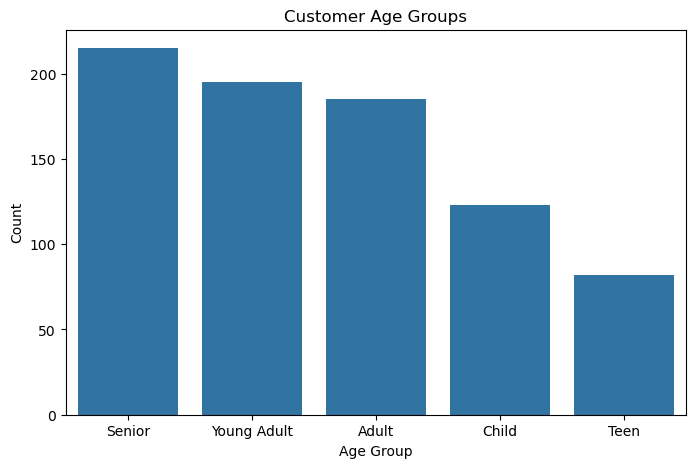

In [39]:


plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Age_Group"],
    order=df["Age_Group"].value_counts().index
)

plt.title("Customer Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

In [40]:
df["Gender"].value_counts()

Gender
Male                 209
Others               202
Female               197
Prefer not to say    192
Name: count, dtype: int64

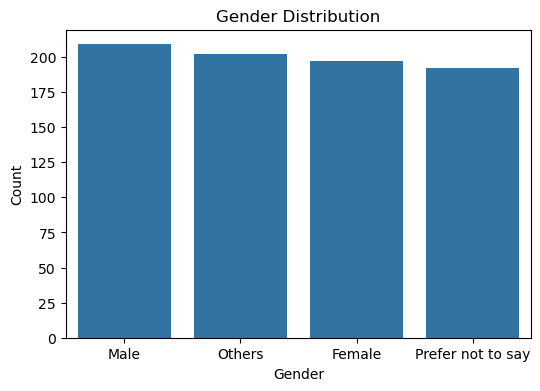

In [42]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["Gender"], order=df["Gender"].value_counts().index)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()